<a href="https://colab.research.google.com/github/somar9/Neutrino-Oscillation-Project/blob/ND-simulation---Gaussian/4flavour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#Clone github repository for neutrino oscilation probability
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact/src
%ls


Cloning into 'NuOscProbExact'...
remote: Enumerating objects: 676, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 676 (delta 55), reused 58 (delta 30), pack-reused 586 (from 1)
Receiving objects: 100% (676/676), 795.36 KiB | 18.50 MiB/s, done.
Resolving deltas: 100% (333/333), done.
/content/NuOscProbExact/src/NuOscProbExact/src
globaldefs.py  hamiltonians2nu.py  hamiltonians3nu.py  oscprob2nu.py  oscprob3nu.py


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from NuOscProbExact.src.oscprob3nu import probabilities_3nu
from NuOscProbExact.src.hamiltonians3nu import hamiltonian_3nu_vacuum_energy_independent, hamiltonian_3nu_matter
from NuOscProbExact.src.globaldefs import *
from oscprob2nu import *
from globaldefs import *
from hamiltonians2nu import *
from NuOscProbExact.src import  oscprob2nu, globaldefs, hamiltonians2nu
import math
from scipy.stats import truncnorm
import copy as cp

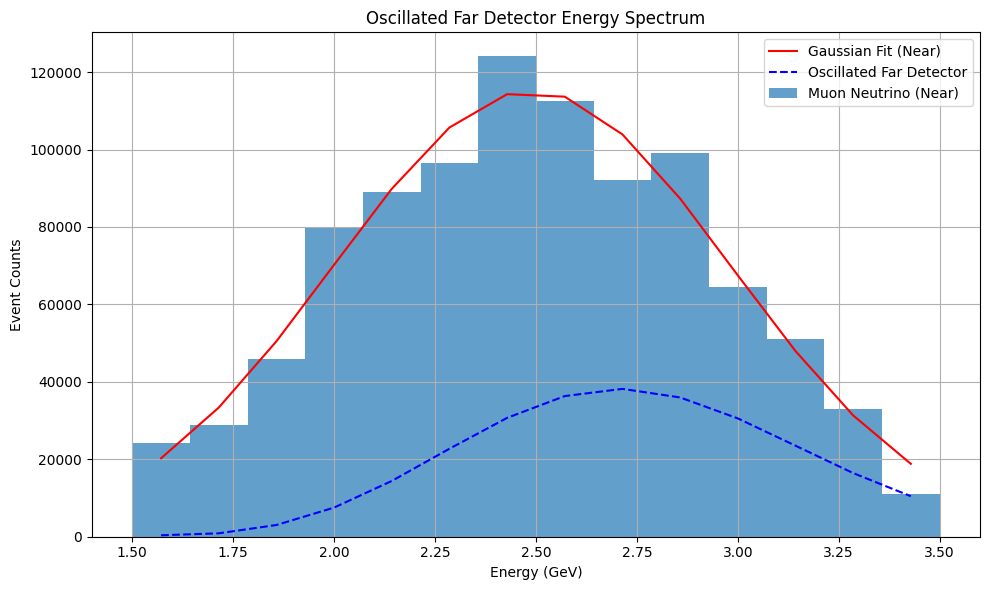

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Parameters
Length_near = 1  # Near detector distance in km
Length_far = 810  # Far detector distance in km

# Define a Gaussian energy distribution in eV
mean_energy = 2.5e9  # Mean energy in eV (corresponds to 2.5 GeV)
sigma_energy = 0.5e9  # Standard deviation in eV
energies = np.random.normal(mean_energy, sigma_energy, 1000)

# Initialize the vacuum Hamiltonian (energy-independent part)
h_vacuum_energy_indep = hamiltonian_3nu_vacuum_energy_independent(
    S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF
)

# Function to compute probabilities with matter effects for a given baseline
def compute_probabilities_matter(baseline, energy_values):
    Prob_mu = []

    for E in energy_values:
        # Define matter Hamiltonian for each energy
        h_matter = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)

        # Calculate muon neutrino survival probability (Pmm)
        _, _, _, _, Pmm, _, _, _, _ = probabilities_3nu(h_matter, baseline * CONV_KM_TO_INV_EV)
        Prob_mu.append(Pmm)

    return np.array(Prob_mu)

# Total number of events for near and far detectors
total_events_near = 1000

# Generate Poisson-distributed event counts based on the probabilities at the near detector
Prob_mu_near = compute_probabilities_matter(Length_near, energies)
counts_mu_near = np.random.poisson(lam=Prob_mu_near * total_events_near)

# Define bin edges and centers for plotting (in eV, will convert later to GeV for plotting)
bin_edges = np.linspace(1.5e9, 3.5e9, 15)  # Fine energy bins (in eV)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# Compute histogram for near detector using the predefined bin edges
hist_near, _ = np.histogram(energies, bins=bin_edges, weights=counts_mu_near)

# Gaussian fitting function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Fit near detector histogram with a Gaussian
popt_near, _ = curve_fit(gaussian, bin_centers, hist_near, p0=[np.max(hist_near), mean_energy, sigma_energy])

# Oscillate near detector Gaussian to compute far detector spectrum
oscillated_far = gaussian(bin_centers, *popt_near) * compute_probabilities_matter(Length_far, bin_centers)

# Plot the histograms and Gaussian fits
plt.figure(figsize=(10, 6))

# Near detector
plt.bar(bin_centers / 1e9, hist_near, width=np.diff(bin_edges) / 1e9, align='center', alpha=0.7, label='Muon Neutrino (Near)')
plt.plot(bin_centers / 1e9, gaussian(bin_centers, *popt_near), 'r-', label='Gaussian Fit (Near)')
plt.xlabel('Energy (GeV)')  # Energy in GeV
plt.ylabel('Event Counts')
plt.title('Oscillated Far Detector Energy Spectrum')

# Oscillated Far detector
plt.plot(bin_centers / 1e9, oscillated_far, 'b--', label='Oscillated Far Detector')

plt.legend()
plt.grid()
plt.tight_layout()

# Remove scientific notation from axis labels
plt.ticklabel_format(style='plain', axis='x')  # This removes scientific notation for x-axis

plt.show()


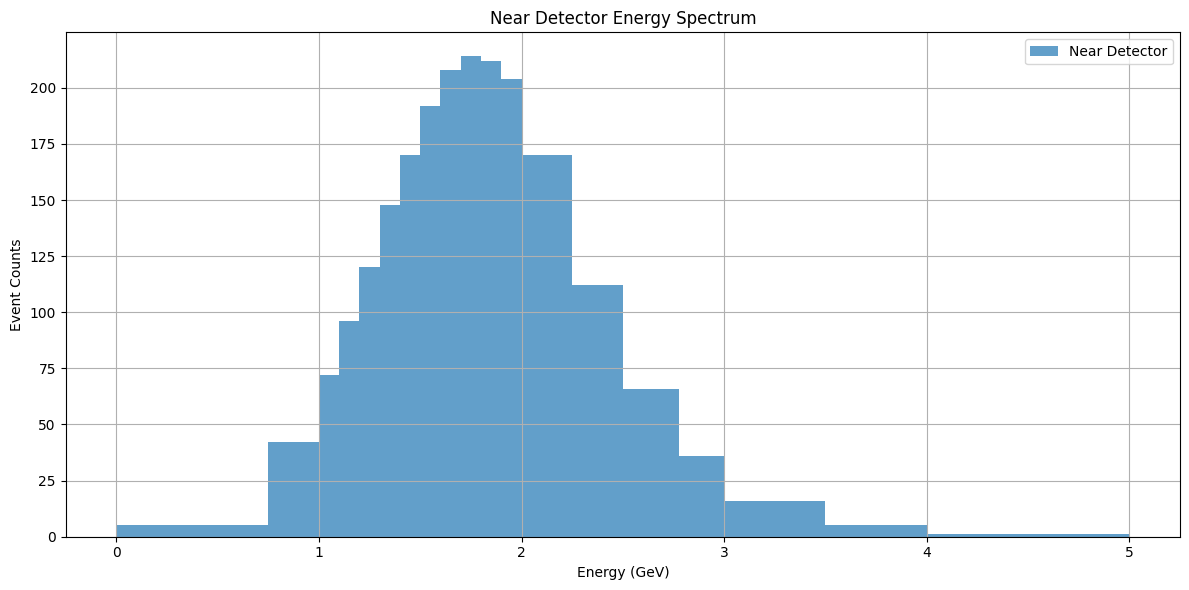

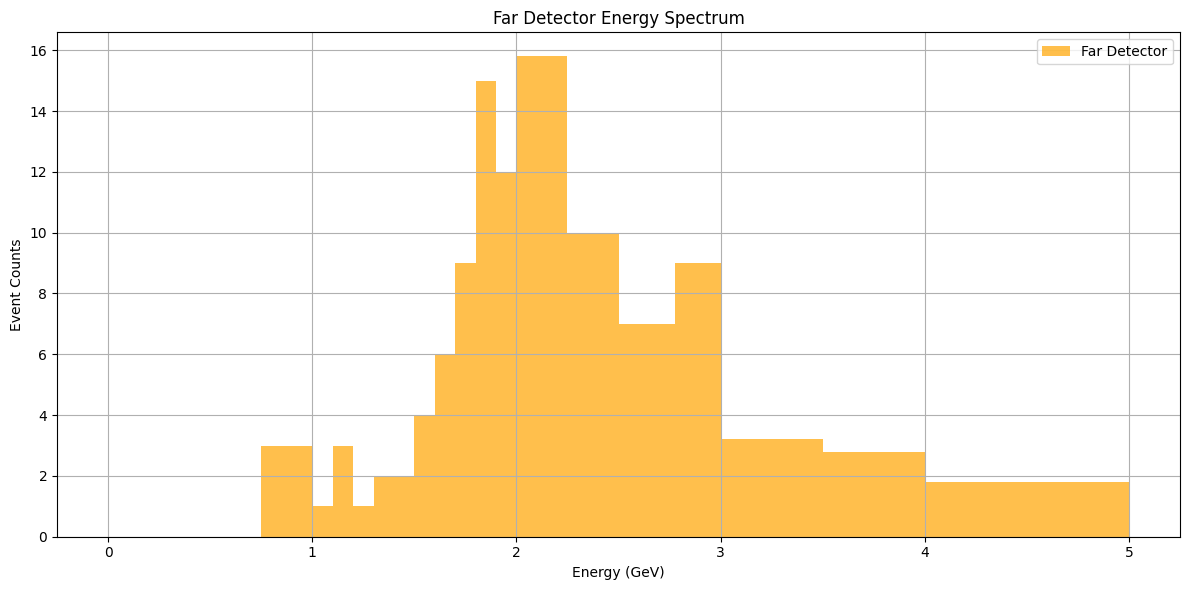

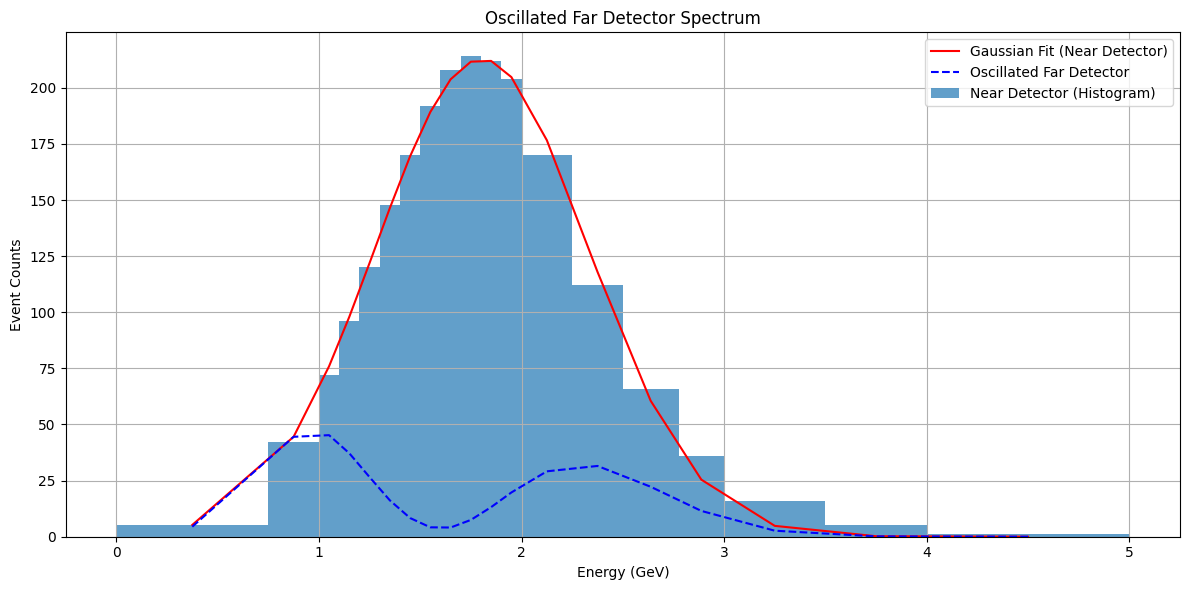

In [54]:
# Given Parameters (Energy values in eV, will convert to GeV for plotting)
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5]) * 1e9  # eV
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5]) * 1e9  # eV
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])
counts_fd = np.array([0, 3, 1, 3, 1, 2, 2, 4, 6, 9, 15, 12, 15.8, 10, 7, 9, 3.2, 2.8, 1.8])

# Detector Parameters
Length_near = 1  # Near detector distance in km
Length_far = 810  # Far detector distance in km

# Initialize the vacuum Hamiltonian
h_vacuum_energy_indep = hamiltonian_3nu_vacuum_energy_independent(
    S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF
)

# Function to compute oscillation probabilities for muon neutrinos
def compute_probabilities_matter(baseline, energy_values):
    Prob_mu = []
    for E in energy_values:
        h_matter = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)
        _, _, _, _, Pmm, _, _, _, _ = probabilities_3nu(h_matter, baseline * CONV_KM_TO_INV_EV)
        Prob_mu.append(Pmm)
    return np.array(Prob_mu)

# Gaussian fitting function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Fit the near detector data with a Gaussian
popt_nd, _ = curve_fit(
    gaussian,
    bin_centers,
    counts_nd,
    p0=[np.max(counts_nd), 2.5e9, 0.5e9]
)

# Compute oscillation probabilities for the far detector
Prob_mu_far = compute_probabilities_matter(Length_far, bin_centers)

# Oscillated far detector spectrum (apply oscillation to fitted Gaussian)
oscillated_fd = gaussian(bin_centers, *popt_nd) * Prob_mu_far / np.max(Prob_mu_far)

# Plotting Near Detector Histogram (Energy axis converted to GeV)
plt.figure(figsize=(12, 6))
plt.bar(bin_centers / 1e9, counts_nd, width=np.diff(bin_edges) / 1e9, align='center', alpha=0.7, label='Near Detector')
plt.xlabel("Energy (GeV)")  # Updated to GeV
plt.ylabel("Event Counts")
plt.title("Near Detector Energy Spectrum")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Plotting Far Detector Histogram (Energy axis converted to GeV)
plt.figure(figsize=(12, 6))
plt.bar(bin_centers / 1e9, counts_fd, width=np.diff(bin_edges) / 1e9, align='center', alpha=0.7, label='Far Detector', color='orange')
plt.xlabel("Energy (GeV)")  # Updated to GeV
plt.ylabel("Event Counts")
plt.title("Far Detector Energy Spectrum")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


# Plot Near Detector and Oscillated Far Detector Histograms (Energy axis converted to GeV)
plt.figure(figsize=(12, 6))

# Near Detector
plt.bar(
    bin_centers / 1e9,  # Convert to GeV
    counts_nd,
    width=np.diff(bin_edges) / 1e9,  # Convert to GeV
    align="center",
    alpha=0.7,
    label="Near Detector (Histogram)"
)
plt.plot(
    bin_centers / 1e9,  # Convert to GeV
    gaussian(bin_centers, *popt_nd),
    "r-",
    label="Gaussian Fit (Near Detector)"
)

# Oscillated Far Detector
plt.plot(
    bin_centers / 1e9,  # Convert to GeV
    oscillated_fd,
    "b--",
    label="Oscillated Far Detector"
)

# Plot settings
plt.xlabel("Energy (GeV)")  # Updated to GeV
plt.ylabel("Event Counts")
plt.title("Oscillated Far Detector Spectrum")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


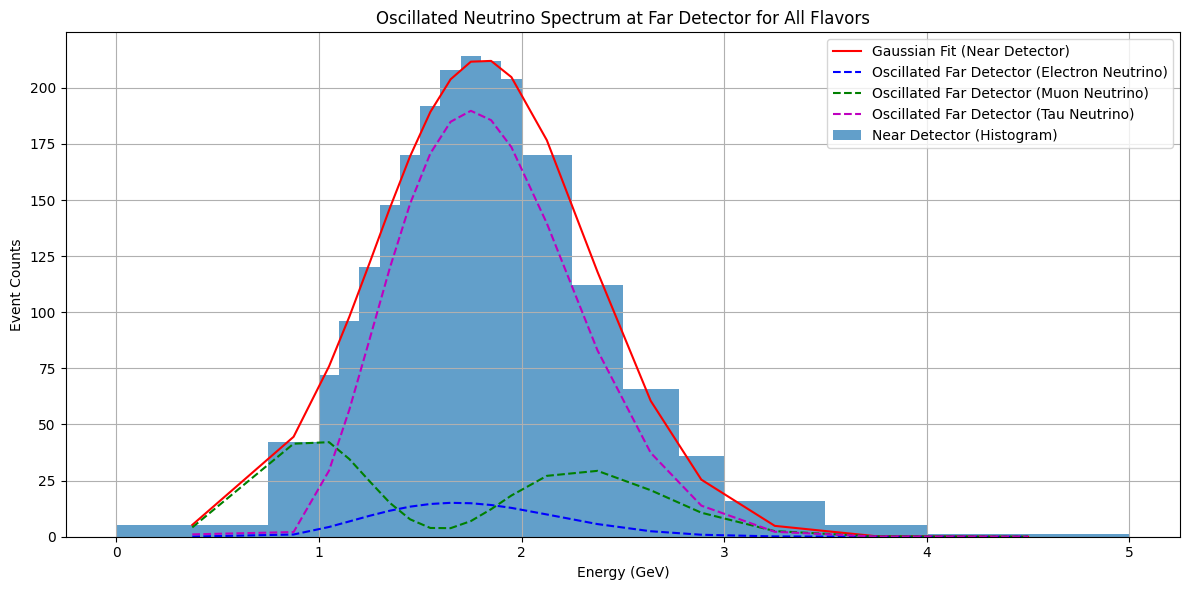

In [55]:
# Function to compute oscillation probabilities for all three flavors
def compute_probabilities_all_flavors(baseline, energy_values):
    Prob_e, Prob_mu, Prob_tau = [], [], []
    for E in energy_values:
        h_matter = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)
        Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt = probabilities_3nu(h_matter, baseline * CONV_KM_TO_INV_EV)
        Prob_e.append(Pme)  # Electron neutrino survival
        Prob_mu.append(Pmm)  # Muon neutrino survival
        Prob_tau.append(Pmt)  # Tau neutrino survival
    return np.array(Prob_e), np.array(Prob_mu), np.array(Prob_tau)

# Compute oscillation probabilities for all flavors at the far detector
Prob_e_far, Prob_mu_far, Prob_tau_far = compute_probabilities_all_flavors(Length_far, bin_centers)

# Generate oscillated far detector spectra for all flavors
oscillated_fd_e = gaussian(bin_centers, *popt_nd) * Prob_e_far
oscillated_fd_mu = gaussian(bin_centers, *popt_nd) * Prob_mu_far
oscillated_fd_tau = gaussian(bin_centers, *popt_nd) * Prob_tau_far

# Plot Near Detector and Oscillated Far Detector Histograms (Energy axis converted to GeV)
plt.figure(figsize=(12, 6))

# Near Detector
plt.bar(
    bin_centers / 1e9,  # Convert to GeV
    counts_nd,
    width=np.diff(bin_edges) / 1e9,  # Convert to GeV
    align="center",
    alpha=0.7,
    label="Near Detector (Histogram)"
)
plt.plot(
    bin_centers / 1e9,  # Convert to GeV
    gaussian(bin_centers, *popt_nd),
    "r-",
    label="Gaussian Fit (Near Detector)"
)

# Oscillated Far Detector for all flavors
plt.plot(
    bin_centers / 1e9,  # Convert to GeV
    oscillated_fd_e,
    "b--",
    label="Oscillated Far Detector (Electron Neutrino)"
)
plt.plot(
    bin_centers / 1e9,  # Convert to GeV
    oscillated_fd_mu,
    "g--",
    label="Oscillated Far Detector (Muon Neutrino)"
)
plt.plot(
    bin_centers / 1e9,  # Convert to GeV
    oscillated_fd_tau,
    "m--",
    label="Oscillated Far Detector (Tau Neutrino)"
)

# Plot settings
plt.xlabel("Energy (GeV)")  # Updated to GeV
plt.ylabel("Event Counts")
plt.title("Oscillated Neutrino Spectrum at Far Detector for All Flavors")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


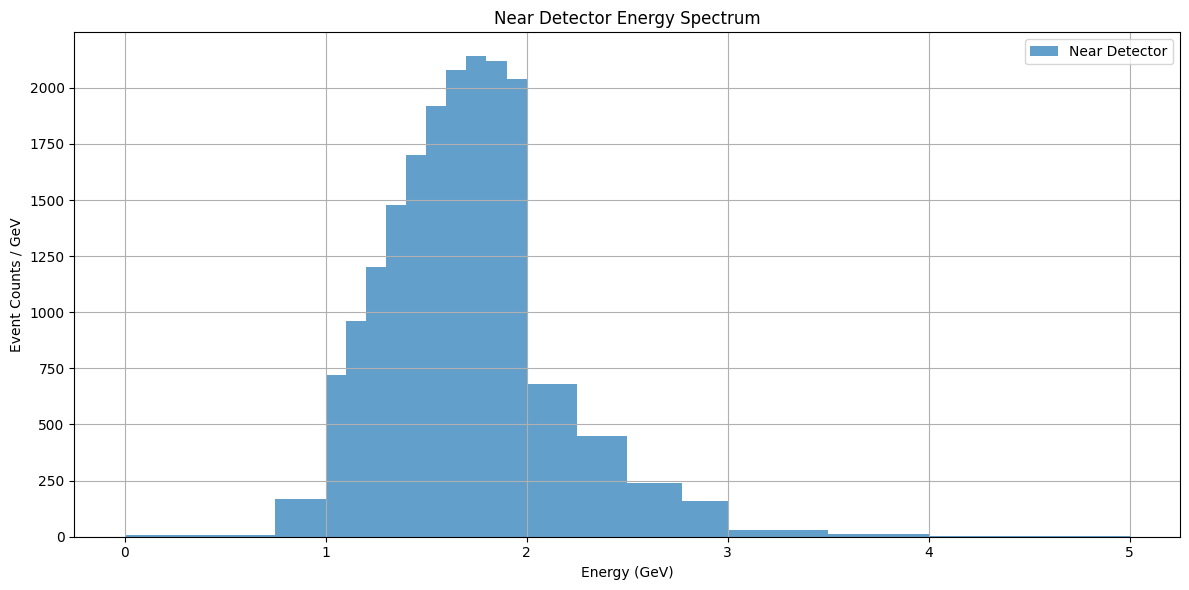

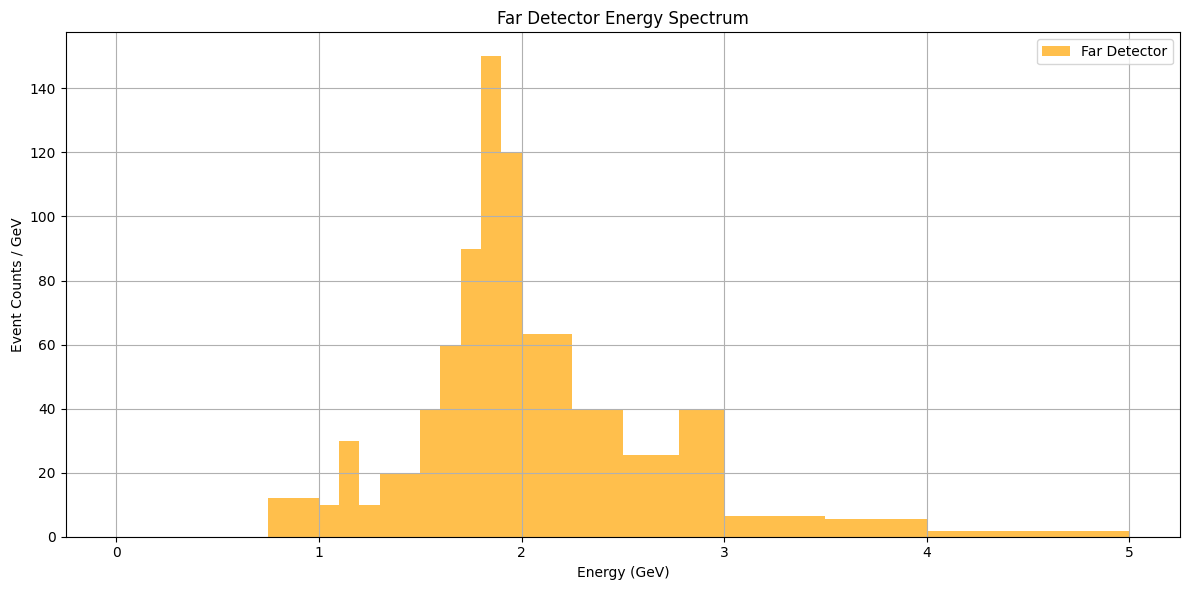

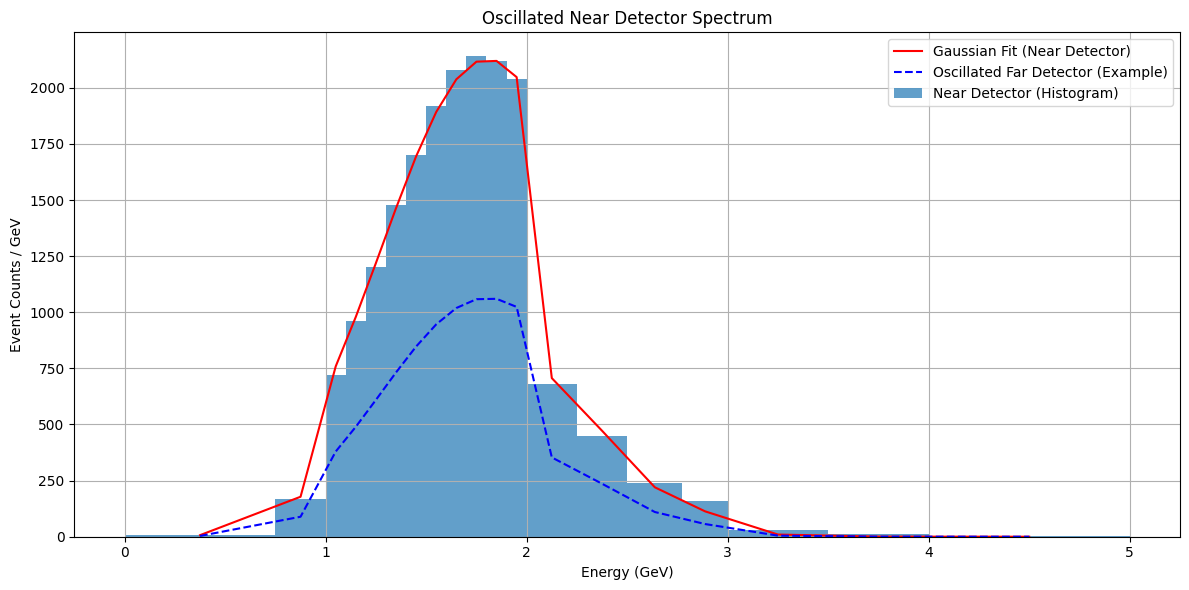

In [35]:
# Given Parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5]) * 1e9  # eV
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5]) * 1e9  # eV
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])
counts_fd = np.array([0, 3, 1, 3, 1, 2, 2, 4, 6, 9, 15, 12, 15.8, 10, 7, 9, 3.2, 2.8, 1.8])

# Rescale bin_centers and bin_edges to GeV
bin_centers_GeV = bin_centers / 1e9  # Convert eV to GeV
bin_edges_GeV = bin_edges / 1e9      # Convert eV to GeV

# Normalize counts by bin widths
bin_widths_GeV = np.diff(bin_edges_GeV)  # Bin widths in GeV
adjusted_counts_nd = counts_nd / bin_widths_GeV  # Normalize Near Detector counts
adjusted_counts_fd = counts_fd / bin_widths_GeV  # Normalize Far Detector counts

# Plotting Near Detector Histogram
plt.figure(figsize=(12, 6))
plt.bar(bin_centers_GeV, adjusted_counts_nd, width=bin_widths_GeV, align='center', alpha=0.7, label='Near Detector')
plt.xlabel("Energy (GeV)")  # Changed label to GeV
plt.ylabel("Event Counts / GeV")
plt.title("Near Detector Energy Spectrum")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Plotting Far Detector Histogram
plt.figure(figsize=(12, 6))
plt.bar(bin_centers_GeV, adjusted_counts_fd, width=bin_widths_GeV, align='center', alpha=0.7, label='Far Detector', color='orange')
plt.xlabel("Energy (GeV)")  # Changed label to GeV
plt.ylabel("Event Counts / GeV")
plt.title("Far Detector Energy Spectrum")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Example Gaussian Fit Function
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# Perform Gaussian Fit for Near Detector Spectrum
popt_nd, _ = curve_fit(gaussian, bin_centers, counts_nd, p0=[200, 1.5e9, 0.5e9])

# Generate Oscillated Far Detector Spectrum (Placeholder Example)
oscillated_fd = gaussian(bin_centers, *popt_nd) * 0.5  # Example scaled Gaussian

# Plot Near Detector and Oscillated Far Detector Spectra
plt.figure(figsize=(12, 6))

# Near Detector
plt.bar(bin_centers_GeV, adjusted_counts_nd, width=bin_widths_GeV, align="center", alpha=0.7, label="Near Detector (Histogram)")
plt.plot(bin_centers_GeV, gaussian(bin_centers, *popt_nd) / bin_widths_GeV, "r-", label="Gaussian Fit (Near Detector)")

# Oscillated Far Detector
plt.plot(bin_centers_GeV, oscillated_fd / bin_widths_GeV, "b--", label="Oscillated Far Detector (Example)")

# Plot settings
plt.xlabel("Energy (GeV)")  # Changed label to GeV
plt.ylabel("Event Counts / GeV")
plt.title("Oscillated Near Detector Spectrum")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


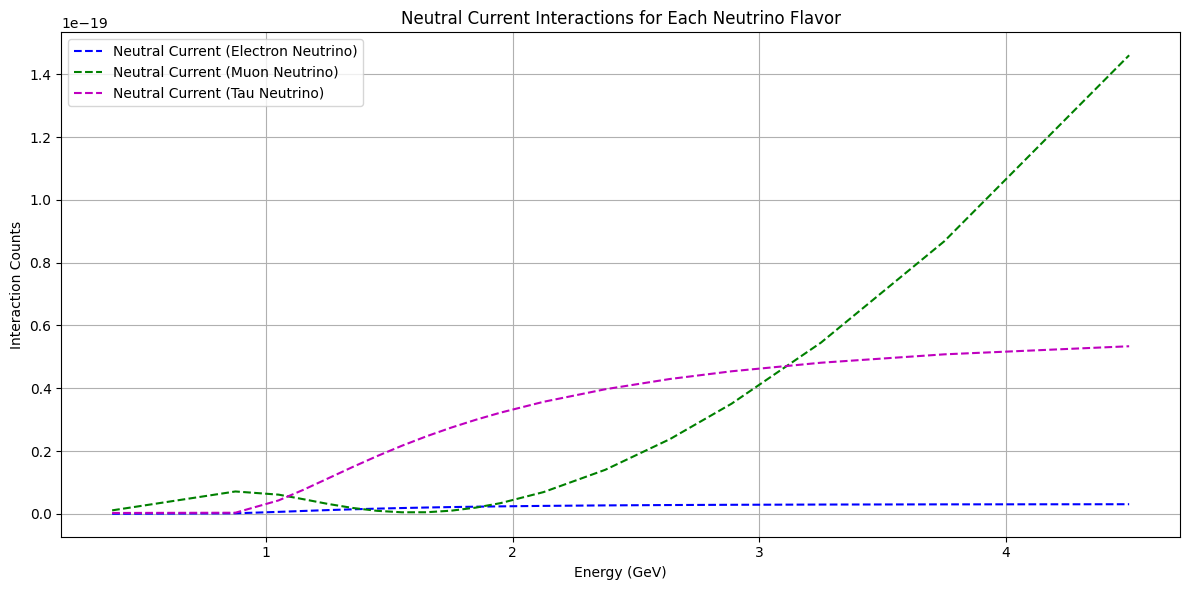

In [20]:
#visualizing Neutral Current (NC) interactions for the three types of neutrinos (electron, muon, and tau) at the Far Detector.
#NC interactions refer to interactions where neutrinos scatter off nucleons without changing flavor (unlike charged current interactions,
#where neutrinos change flavor after interacting).



# Define neutral current interaction cross-section model (example function)
def neutral_current_cross_section(energy):
    # This is a placeholder; the actual cross-section should depend on the neutrino energy
    # For simplicity, assume it scales with energy squared, for example.
    return 1e-38 * energy**2  # Example scaling, units in cm^2

# Function to compute neutral current interaction spectra
def compute_nc_interactions(energy_values, Prob_e, Prob_mu, Prob_tau):
    nc_e = neutral_current_cross_section(energy_values) * Prob_e
    nc_mu = neutral_current_cross_section(energy_values) * Prob_mu
    nc_tau = neutral_current_cross_section(energy_values) * Prob_tau
    return nc_e, nc_mu, nc_tau

# Compute the neutral current interaction spectra for each neutrino flavor
nc_e_far, nc_mu_far, nc_tau_far = compute_nc_interactions(bin_centers, Prob_e_far, Prob_mu_far, Prob_tau_far)

# Plotting Near Detector and Oscillated Far Detector Spectra (Neutral Current Interactions)
plt.figure(figsize=(12, 6))

# Neutral Current Interactions for each flavor
plt.plot(
    bin_centers_GeV,
    nc_e_far,
    "b--",
    label="Neutral Current (Electron Neutrino)"
)
plt.plot(
    bin_centers_GeV,
    nc_mu_far,
    "g--",
    label="Neutral Current (Muon Neutrino)"
)
plt.plot(
    bin_centers_GeV,
    nc_tau_far,
    "m--",
    label="Neutral Current (Tau Neutrino)"
)

# Plot settings
plt.xlabel("Energy (GeV)")
plt.ylabel("Interaction Counts")
plt.title("Neutral Current Interactions for Each Neutrino Flavor")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [39]:
# simplified 4-flavor neutrino oscillation model


# Sector-specific parameters (add these or fetch from globaldefs)
def get_mixing_and_delta(sector, transition):
    if sector == '12':
        mixing_angle = globaldefs.S12_NO_BF
        delta_mass_squared = globaldefs.D21_NO_BF
        transition_map = {'me': 2, 'mm': 3}
    elif sector == '23':
        mixing_angle = globaldefs.S23_NO_BF
        delta_mass_squared = globaldefs.D31_NO_BF
        transition_map = {'mm': 0, 'mt': 1}
    else:
        raise ValueError(f"Invalid sector '{sector}'. Must be '12' or '23'.")

    index1 = transition_map.get(transition)
    if index1 is None:
        raise ValueError(f"Invalid transition '{transition}'. Must match the sector.")

    return mixing_angle, delta_mass_squared, index1

# Example usage:
sector = '12'
transition = 'me'
mixing_angle, delta_mass_squared, index1 = get_mixing_and_delta(sector, transition)

# Hamiltonian for 4 flavors (adapted for simplicity)
def hamiltonian_4flavor(E, L, U, delta_m2):
    # Diagonal mass squared differences (in eV^2)
    H_diag = np.diag([0, delta_m2[0], delta_m2[1], delta_m2[2]])
    # Hamiltonian (vacuum oscillation)
    H = (1 / (2 * E)) * np.dot(np.dot(U, H_diag), np.linalg.inv(U))
    return H

# Define the 4-flavor mixing matrix (simplified example)
U = np.array([
    [np.cos(mixing_angle), np.sin(mixing_angle), 0, 0],
    [-np.sin(mixing_angle) * np.cos(mixing_angle), np.cos(mixing_angle) * np.cos(mixing_angle), np.sin(mixing_angle), 0],
    [np.sin(mixing_angle) * np.sin(mixing_angle), -np.cos(mixing_angle) * np.sin(mixing_angle), np.cos(mixing_angle), 0],
    [0, 0, 0, 1]  # Assuming small mixing between the active and sterile neutrinos
])

# Energy (GeV), baseline (km), and delta_m2 for oscillation (eV^2)
E = 1.0  # GeV
L = 1000  # km
delta_m2 = [delta_m21_sq, delta_m31_sq, delta_m41_sq]  # eV^2 for each transition

# Calculate Hamiltonian for 4-flavor system
H = hamiltonian_4flavor(E, L, U, delta_m2)

# Example function to calculate oscillation probabilities
def oscillation_probabilities(E, L, U, delta_m2):
    H = hamiltonian_4flavor(E, L, U, delta_m2)
    P_emu = np.abs(U[0, 1] * np.exp(-1j * H[0, 1] * L) + U[1, 1] * np.exp(-1j * H[1, 1] * L))**2
    return P_emu

# Get the probability for this transition
probability = oscillation_probabilities(E, L, U, delta_m2)
print(f"Oscillation Probability P(ν_e -> ν_μ): {probability}")

Oscillation Probability P(ν_e -> ν_μ): 1.513170913322196


These neutrinos oscillate into one another, and the evolution of these oscillations is governed by a Hamiltonian, which depends on the neutrino energy, the baseline, and the mixing angles between the neutrino flavors.

Mixing angles determine the probability of transitions between neutrino flavors.
Mass squared differences between the neutrino states are critical for oscillation, as they influence the frequency of oscillation.


lacking : This code assumes a simple 4-flavor mixing matrix and does not account for all possible oscillation parameters (e.g., the mixing angles for all 4 neutrino states and the exact mass squared differences).
It also assumes small mixing between active and sterile neutrinos, which may not be true in all models.


In [44]:
# Sector-specific parameters (example values)
def get_mixing_and_delta(sector, transition):
    if sector == '12':
        mixing_angle = 0.8  # Example value for S12 (radians)
        delta_mass_squared = [7.53e-5, 2.44e-3, 1.0e-4]  # Example mass squared differences [Δm²₁₂, Δm²₃₁, Δm²₄₁]
        transition_map = {'me': 2, 'mm': 3}
    elif sector == '23':
        mixing_angle = 0.6  # Example value for S23 (radians)
        delta_mass_squared = [2.44e-3, 2.44e-3, 1.0e-4]  # Example mass squared differences [Δm²₃₂, Δm²₄₂]
        transition_map = {'mm': 0, 'mt': 1}
    else:
        raise ValueError(f"Invalid sector '{sector}'. Must be '12' or '23'.")

    index1 = transition_map.get(transition)
    if index1 is None:
        raise ValueError(f"Invalid transition '{transition}'. Must match the sector.")

    return mixing_angle, delta_mass_squared, index1

# Example usage:
sector = '12'
transition = 'me'
mixing_angle, delta_mass_squared, index1 = get_mixing_and_delta(sector, transition)

# Define the complete 4-flavor mixing matrix (with small mixing to sterile neutrinos)
U = np.array([
    [np.cos(mixing_angle), np.sin(mixing_angle), 0, 0],
    [-np.sin(mixing_angle) * np.cos(mixing_angle), np.cos(mixing_angle) * np.cos(mixing_angle), np.sin(mixing_angle), 0],
    [np.sin(mixing_angle) * np.sin(mixing_angle), -np.cos(mixing_angle) * np.sin(mixing_angle), np.cos(mixing_angle), 0],
    [0.1, 0.1, 0.1, 1]  # Small mixing between active and sterile neutrinos (example)
])

# Hamiltonian for 4-flavor system (with active-sterile mixing)
def hamiltonian_4flavor(E, L, U, delta_m2):
    # Diagonal mass squared differences (in eV^2)
    H_diag = np.diag([0, delta_m2[0], delta_m2[1], delta_m2[2]])
    # Hamiltonian (vacuum oscillation)
    H = (1 / (2 * E)) * np.dot(np.dot(U, H_diag), np.linalg.inv(U))
    return H

# Energy (GeV), baseline (km), and delta_m2 for oscillation (eV^2)
E = 1.0  # GeV
L = 1000  # km
delta_m2 = delta_mass_squared  # eV^2 for each transition (active-active and active-sterile)

# Calculate Hamiltonian for 4-flavor system
H = hamiltonian_4flavor(E, L, U, delta_m2)

# Function to calculate the oscillation probabilities
def oscillation_probabilities(E, L, U, delta_m2):
    H = hamiltonian_4flavor(E, L, U, delta_m2)

    # Calculate the time evolution operator (using matrix exponential for oscillations)
    U_evolution = np.exp(-1j * H * L)

    # Oscillation probability P(ν_e -> ν_μ), P(ν_e -> ν_τ), and P(ν_e -> ν_s)
    P_emu = np.abs(np.dot(U[0], U_evolution[0, 1]))**2  # P(ν_e -> ν_μ)
    P_etu = np.abs(np.dot(U[0], U_evolution[0, 2]))**2  # P(ν_e -> ν_τ)
    P_est = np.abs(np.dot(U[0], U_evolution[0, 3]))**2  # P(ν_e -> ν_s)

    # Return the probabilities
    return P_emu, P_etu, P_est

# Get the probability for these transitions
P_emu, P_etu, P_est = oscillation_probabilities(E, L, U, delta_m2)

# Output the results
print(f"Oscillation Probability P(ν_e -> ν_μ): {P_emu}")
print(f"Oscillation Probability P(ν_e -> ν_τ): {P_etu}")
print(f"Oscillation Probability P(ν_e -> ν_s): {P_est}")

Oscillation Probability P(ν_e -> ν_μ): [0.48540024 0.51459976 0.         0.        ]
Oscillation Probability P(ν_e -> ν_τ): [0.48540024 0.51459976 0.         0.        ]
Oscillation Probability P(ν_e -> ν_s): [0.48540024 0.51459976 0.         0.        ]


In [45]:
import numpy as np

# Sector-specific parameters (example values)
def get_mixing_and_delta(sector, transition):
    if sector == '12':
        mixing_angle = 0.8  # Example value for S12 (radians)
        delta_mass_squared = [7.53e-5, 2.44e-3, 1.0e-4]  # Example mass squared differences [Δm²₁₂, Δm²₃₁, Δm²₄₁]
        transition_map = {'me': 2, 'mm': 3}
    elif sector == '23':
        mixing_angle = 0.6  # Example value for S23 (radians)
        delta_mass_squared = [2.44e-3, 2.44e-3, 1.0e-4]  # Example mass squared differences [Δm²₃₂, Δm²₄₂]
        transition_map = {'mm': 0, 'mt': 1}
    else:
        raise ValueError(f"Invalid sector '{sector}'. Must be '12' or '23'.")

    index1 = transition_map.get(transition)
    if index1 is None:
        raise ValueError(f"Invalid transition '{transition}'. Must match the sector.")

    return mixing_angle, delta_mass_squared, index1

# Example usage:
sector = '12'
transition = 'me'
mixing_angle, delta_mass_squared, index1 = get_mixing_and_delta(sector, transition)

# Define the complete 4-flavor mixing matrix (with small mixing to sterile neutrinos)
U = np.array([
    [np.cos(mixing_angle), np.sin(mixing_angle), 0, 0],
    [-np.sin(mixing_angle) * np.cos(mixing_angle), np.cos(mixing_angle) * np.cos(mixing_angle), np.sin(mixing_angle), 0],
    [np.sin(mixing_angle) * np.sin(mixing_angle), -np.cos(mixing_angle) * np.sin(mixing_angle), np.cos(mixing_angle), 0],
    [0.1, 0.1, 0.1, 1]  # Small mixing between active and sterile neutrinos (example)
])

# Hamiltonian for 4-flavor system (with active-sterile mixing)
def hamiltonian_4flavor(E, L, U, delta_m2):
    # Diagonal mass squared differences (in eV^2)
    H_diag = np.diag([0, delta_m2[0], delta_m2[1], delta_m2[2]])
    # Hamiltonian (vacuum oscillation)
    H = (1 / (2 * E)) * np.dot(np.dot(U, H_diag), np.linalg.inv(U))
    return H

# Energy (GeV), baseline (km), and delta_m2 for oscillation (eV^2)
E = 1.0  # GeV
L = 1000  # km
delta_m2 = delta_mass_squared  # eV^2 for each transition (active-active and active-sterile)

# Calculate Hamiltonian for 4-flavor system
H = hamiltonian_4flavor(E, L, U, delta_m2)

# Function to calculate the oscillation probabilities for specific transitions
def oscillation_probabilities(E, L, U, delta_m2, transition):
    # Get the Hamiltonian for the 4-flavor system
    H = hamiltonian_4flavor(E, L, U, delta_m2)

    # Calculate the time evolution operator (using matrix exponential for oscillations)
    U_evolution = np.exp(-1j * H * L)

    # Different transition cases
    if transition == 'me':  # ν_e -> ν_μ
        P = np.abs(np.dot(U[0], U_evolution[0, 1]))**2
    elif transition == 'mt':  # ν_e -> ν_τ
        P = np.abs(np.dot(U[0], U_evolution[0, 2]))**2
    elif transition == 'ms':  # ν_e -> ν_s (sterile neutrino)
        P = np.abs(np.dot(U[0], U_evolution[0, 3]))**2
    elif transition == 'mm':  # ν_μ -> ν_μ
        P = np.abs(np.dot(U[1], U_evolution[1, 1]))**2
    elif transition == 'mtau':  # ν_μ -> ν_τ
        P = np.abs(np.dot(U[1], U_evolution[1, 2]))**2
    elif transition == 'ms':  # ν_μ -> ν_s
        P = np.abs(np.dot(U[1], U_evolution[1, 3]))**2
    elif transition == 'tau':  # ν_τ -> ν_τ
        P = np.abs(np.dot(U[2], U_evolution[2, 2]))**2
    else:
        raise ValueError(f"Invalid transition: {transition}")

    return P

# Get the probability for the desired transition
P = oscillation_probabilities(E, L, U, delta_m2, 'me')
print(f"Oscillation Probability P(ν_e -> ν_μ): {P}")


Oscillation Probability P(ν_e -> ν_μ): [0.48540024 0.51459976 0.         0.        ]
